# Results and Data Analysis for Movie Recommender

This notebook provides visualizations for the Project Report's **Results and Discussion** section. 
It includes exploratory data analysis (EDA) of the input datasets and graphs depicting the evaluation metrics of our recommendation system.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
from data_loader import load_movies, load_ratings
from evaluation import compute_metrics

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Dataset Overview

In [2]:
# Load data using the backend's data_loader
movies_df = load_movies()
ratings_df = load_ratings()

print(f"Total Movies: {len(movies_df):,}")
print(f"Total Ratings: {len(ratings_df):,}")

Total Movies: 10,329
Total Ratings: 105,339


## 2. Distribution of Ratings
Visualizing how users rate movies. Are people generally generous or strict with their ratings?

C:\Users\catch\AppData\Local\Temp\ipykernel_14168\1847144992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='rating', data=ratings_df, palette='viridis')


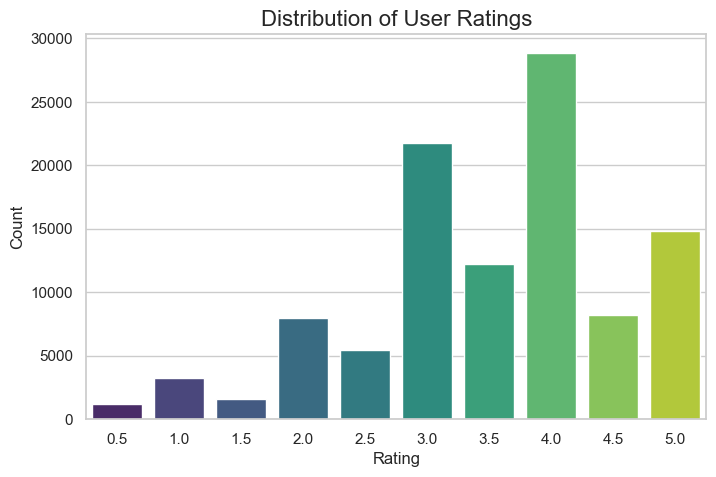

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='rating', data=ratings_df, palette='viridis')
plt.title('Distribution of User Ratings', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()
ax.figure.savefig("rating_distribution.png", dpi=300)

## 3. Top Genres in the Dataset

C:\Users\catch\AppData\Local\Temp\ipykernel_14168\843008020.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='mako')


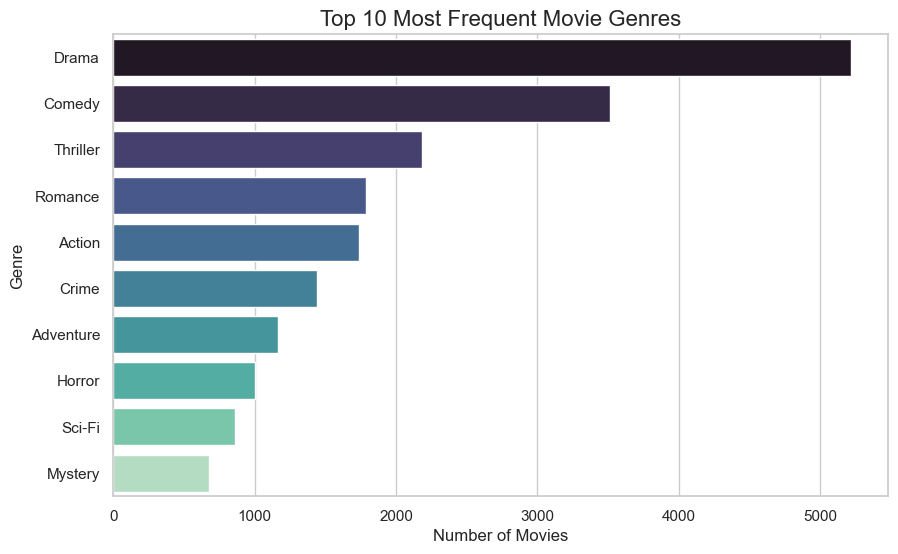

In [4]:
# Split the genres string into individual genres, then explode into separate rows
genres_exploded = movies_df['genres'].str.split('|').explode()
genre_counts = genres_exploded.value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='mako')
plt.title('Top 10 Most Frequent Movie Genres', fontsize=16)
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()
ax.figure.savefig("top_genres.png", dpi=300)

## 4. Model Evaluation Metrics
We compute the RMSE, MAE, Precision@10, and Recall@10 from our `evaluation.py` module. 
*Note: This might take a few seconds as it calculates SVD across the dataset matrix.*

In [5]:
print("Computing Hybrid Model Metrics... (This may take a moment)")
metrics = compute_metrics(k=10)

print("---- Final Metrics ----")
for k, v in metrics.items():
    print(f"{k.upper()}: {v}")

Computing Hybrid Model Metrics... (This may take a moment)
---- Final Metrics ----
RMSE: 3.2217
MAE: 3.0159
PRECISION_AT_10: 0.1917
RECALL_AT_10: 0.1968


### Visualizing the Error Metrics (RMSE & MAE)

C:\Users\catch\AppData\Local\Temp\ipykernel_14168\2482957957.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(error_metrics.keys()), y=list(error_metrics.values()), palette='Reds_d')


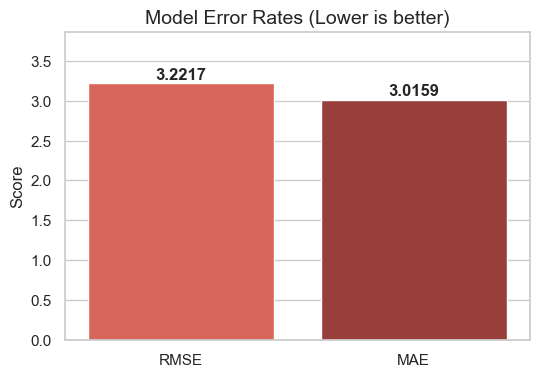

In [6]:
error_metrics = {'RMSE': metrics['rmse'], 'MAE': metrics['mae']}

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=list(error_metrics.keys()), y=list(error_metrics.values()), palette='Reds_d')
plt.title('Model Error Rates (Lower is better)', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, max(error_metrics.values()) * 1.2)
for i, v in enumerate(error_metrics.values()):
    ax.text(i, v + 0.05, str(round(v, 4)), ha='center', fontweight='bold')
plt.show()
ax.figure.savefig("error_metrics.png", dpi=300)

### Visualizing Retrieval Accuracy (Precision & Recall @ 10)

C:\Users\catch\AppData\Local\Temp\ipykernel_14168\286486890.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(retrieval_metrics.keys()), y=list(retrieval_metrics.values()), palette='Blues_d')


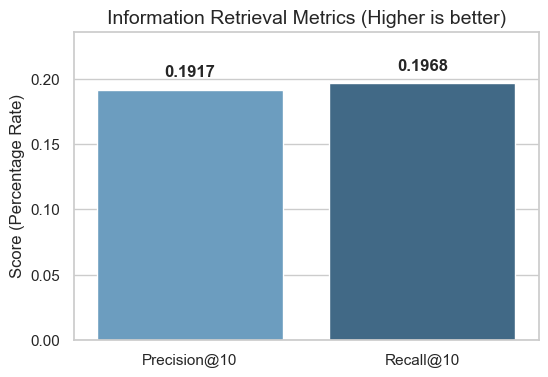

In [7]:
retrieval_metrics = {'Precision@10': metrics['precision_at_10'], 'Recall@10': metrics['recall_at_10']}

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=list(retrieval_metrics.keys()), y=list(retrieval_metrics.values()), palette='Blues_d')
plt.title('Information Retrieval Metrics (Higher is better)', fontsize=14)
plt.ylabel('Score (Percentage Rate)', fontsize=12)
plt.ylim(0, max(retrieval_metrics.values()) * 1.2)
for i, v in enumerate(retrieval_metrics.values()):
    ax.text(i, v + 0.01, str(round(v, 4)), ha='center', fontweight='bold')
plt.show()
ax.figure.savefig("retrieval_metrics.png", dpi=300)